In [111]:
!pip install yfinance

In [112]:
!pip install pykalman

In [113]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download MSFT data (long horizon is important)
msft = yf.download(
    "MSFT",
    start="2015-01-01",
    end="2024-01-01",
    progress=False
)

# Handle MultiIndex columns if present
if isinstance(msft.columns, pd.MultiIndex):
    msft.columns = msft.columns.get_level_values(0)

# Keep relevant columns
msft = msft[['Close', 'Volume']].copy()
msft.rename(columns={'Close': 'price'}, inplace=True)

msft.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_21892\3758809637.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download(


Price,price,Volume
Date,,
2015-01-02,39.858452,27913900
2015-01-05,39.491924,39673900
2015-01-06,38.912289,36447900
2015-01-07,39.406685,29114100
2015-01-08,40.565948,29645200


In [114]:
# Ensure Volume is a Series
volume = msft['Volume']

# Log returns
msft['log_return'] = np.log(msft['price'] / msft['price'].shift(1))

# Lagged returns
msft['lag_1'] = msft['log_return'].shift(1)
msft['lag_5'] = msft['log_return'].shift(5)

# Moving averages
msft['ma_5'] = msft['price'].rolling(5).mean()
msft['ma_20'] = msft['price'].rolling(20).mean()
msft['ma_60'] = msft['price'].rolling(60).mean()

# Momentum
msft['momentum_10'] = msft['price'] - msft['price'].shift(10)

# Volatility
msft['vol_20'] = msft['log_return'].rolling(20).std()
msft['vol_60'] = msft['log_return'].rolling(60).std()

# Volume features
msft['vol_ma_20'] = volume.rolling(20).mean()
msft['volume_ratio'] = volume / msft['vol_ma_20']

In [115]:
from pykalman import KalmanFilter

# Select features and target
features = [
    'lag_1', 'lag_5',
    'momentum_10',
    'vol_20', 'vol_60',
    'volume_ratio'
]
#Adding many derived features increases dimensionality, creates multicollinearity, risks overfitting, and can destabilize the Kalman estimation.

# Drop NaNs ONLY ONCE, here
data = msft[['price'] + features + ['log_return']].dropna()

print("Final dataset shape:", data.shape)

# Safety check
if data.shape[0] < 100:
    raise ValueError("Too little data for Kalman Filter. Increase date range.")

y = data['log_return'].values
X = data[features].values

n_timesteps, n_features = X.shape

# Observation matrix: (T, 1, n_features)
observation_matrices = X.reshape(n_timesteps, 1, n_features)

# Kalman Filter
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_features,
    initial_state_mean=np.zeros(n_features),
    initial_state_covariance=np.eye(n_features),
    transition_matrices=np.eye(n_features),
    observation_matrices=observation_matrices,
    observation_covariance=0.001,
    transition_covariance=0.01 * np.eye(n_features)
)

state_means, state_covs = kf.filter(y)

Final dataset shape: (2204, 8)


In [116]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np

# Kalman-predicted return (time-varying regression)
# r̂_t = X_t · β_t
kalman_pred = np.sum(state_means * X, axis=1)

# ML feature set
ml_features = np.column_stack([kalman_pred, X])

# Target: next-day return (ALIGNED)
y_ml = data['log_return'].shift(-1).values

# Remove last row (no next-day target)
ml_features = ml_features[:-1]
y_ml = y_ml[:-1]

# Standardize features
scaler = StandardScaler()
ml_features = scaler.fit_transform(ml_features)

# Train-test split (70–30, time-ordered)
split = int(0.7 * len(ml_features))
X_train, X_test = ml_features[:split], ml_features[split:]
y_train, y_test = y_ml[:split], y_ml[split:]

# Ridge regression
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predictions
predicted_returns = model.predict(ml_features)

In [117]:
# Trading parameters
threshold = 0.001
transaction_cost = 0.0005

# Generate trading signals
signals = np.where(
    predicted_returns > threshold, 1,
    np.where(predicted_returns < -threshold, -1, 0)
)

# Backtest DataFrame (USE data, not msft)
msft_bt = data.iloc[:-1].copy()   # last row removed earlier
msft_bt['signal'] = signals

# Position (enter at next day open assumption)
msft_bt['position'] = msft_bt['signal'].shift(1).fillna(0)

# Strategy returns
msft_bt['strategy_return'] = msft_bt['position'] * msft_bt['log_return']

# Transaction costs (when position changes)
msft_bt['strategy_return'] -= (
    transaction_cost * msft_bt['position'].diff().abs().fillna(0)
)

# Equity curves
msft_bt['equity'] = (1 + msft_bt['strategy_return']).cumprod()
msft_bt['buy_hold'] = (1 + msft_bt['log_return']).cumprod()

In [118]:
# Performance metrics

# Strategy returns (drop NaNs just in case)
rets = msft_bt['strategy_return'].dropna()

# Cumulative return
cumulative_return = msft_bt['equity'].iloc[-1] - 1

# Annualized Sharpe Ratio
if rets.std() != 0:
    sharpe_ratio = (rets.mean() / rets.std()) * np.sqrt(252)
else:
    sharpe_ratio = 0.0

# Drawdown
rolling_max = msft_bt['equity'].cummax()
drawdown = (rolling_max - msft_bt['equity']) / rolling_max
max_drawdown = drawdown.max()

# Win / Loss ratio
wins = (rets > 0).sum()
losses = (rets < 0).sum()
win_loss_ratio = wins / losses if losses != 0 else np.nan

# Buy & Hold metrics
bh_rets = msft_bt['log_return'].dropna()
bh_cum_return = msft_bt['buy_hold'].iloc[-1] - 1

if bh_rets.std() != 0:
    bh_sharpe = (bh_rets.mean() / bh_rets.std()) * np.sqrt(252)
else:
    bh_sharpe = 0.0

# Print results
print("STRATEGY PERFORMANCE")
print("-" * 40)
print(f"Cumulative Return      : {cumulative_return:.2%}")
print(f"Sharpe Ratio           : {sharpe_ratio:.3f}")
print(f"Maximum Drawdown       : {max_drawdown:.2%}")
print(f"Win/Loss Ratio         : {win_loss_ratio:.2f}")

print("\nBUY & HOLD PERFORMANCE")
print("-" * 40)
print(f"Cumulative Return      : {bh_cum_return:.2%}")
print(f"Sharpe Ratio           : {bh_sharpe:.3f}")

STRATEGY PERFORMANCE
----------------------------------------
Cumulative Return      : 390.19%
Sharpe Ratio           : 0.839
Maximum Drawdown       : 35.57%
Win/Loss Ratio         : 0.73

BUY & HOLD PERFORMANCE
----------------------------------------
Cumulative Return      : 649.91%
Sharpe Ratio           : 0.970


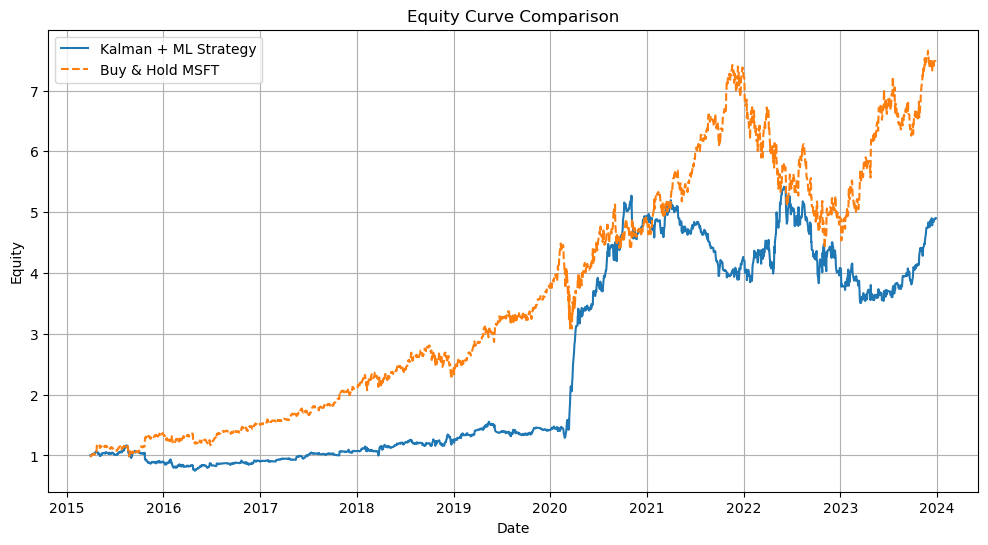

In [119]:
plt.figure(figsize=(12, 6))
plt.plot(msft_bt.index, msft_bt['equity'], label='Kalman + ML Strategy')
plt.plot(msft_bt.index, msft_bt['buy_hold'], label='Buy & Hold MSFT', linestyle='--')
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(True)
plt.show()

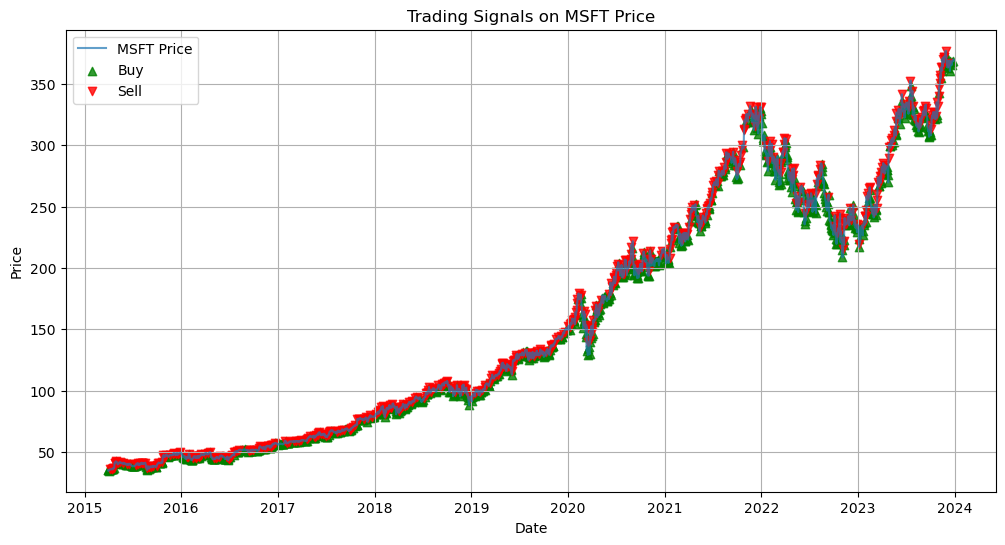

In [120]:
plt.figure(figsize=(12, 6))
plt.plot(msft_bt.index, msft_bt['price'], label='MSFT Price', alpha=0.7)

plt.scatter(
    msft_bt.index[msft_bt['signal'] == 1],
    msft_bt.loc[msft_bt['signal'] == 1, 'price'],
    marker='^', color='green', label='Buy', alpha=0.8
)

plt.scatter(
    msft_bt.index[msft_bt['signal'] == -1],
    msft_bt.loc[msft_bt['signal'] == -1, 'price'],
    marker='v', color='red', label='Sell', alpha=0.8
)

plt.title('Trading Signals on MSFT Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

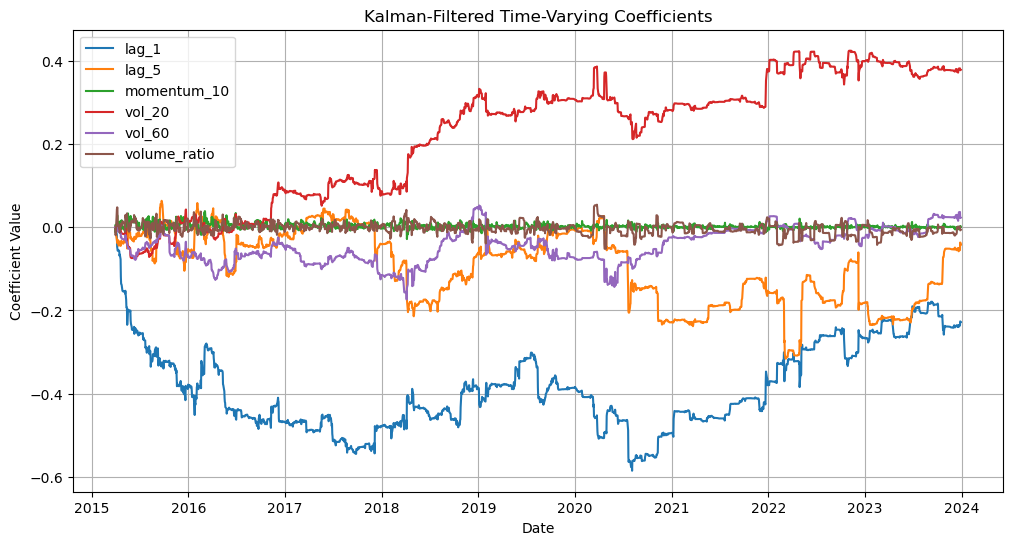

In [121]:
plt.figure(figsize=(12, 6))

for i, feat in enumerate(features):
    plt.plot(data.index, state_means[:, i], label=feat)

plt.title('Kalman-Filtered Time-Varying Coefficients')
plt.xlabel('Date')
plt.ylabel('Coefficient Value')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

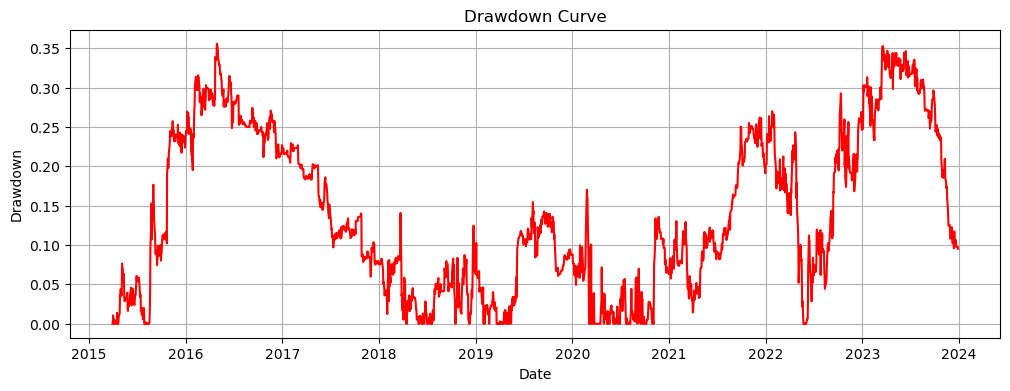

In [122]:
plt.figure(figsize=(12, 4))
plt.plot(msft_bt.index, drawdown, color='red')
plt.title('Drawdown Curve')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.show()